# Smoothing and entropy: a companion notebook

**Human Language Technologies 2026-27, Lecture 05.** Claudio Gallicchio, University of Pisa.

This notebook lets you run the examples of the lecture and check the exercises of the exercise sheet. It follows Chapter 3 of Jurafsky and Martin, *Speech and Language Processing* (3rd edition draft, August 2026), sections 3.6 and 3.7: Laplace and add-k smoothing, interpolation, stupid backoff, entropy, cross-entropy and perplexity.

1. The zero problem on the *I am Sam* corpus
2. Laplace and add-k smoothing
3. A larger corpus: training, development and test sets
4. Interpolation, with the weights set on held-out data
5. Stupid backoff
6. Entropy and codes
7. Cross-entropy and perplexity

How to use it: run the cells from top to bottom (Jupyter, VS Code or Google Colab). Only the Python standard library and `matplotlib` are needed, and no internet connection. Everything is written from scratch, in a few lines, so that you can read it.

## 1. The zero problem

The corpus of the lecture, with the start and end symbols. As in the lecture, unigram counts include `</s>` but not `<s>` (N = 17), and the vocabulary of possible next tokens is the ten words and `</s>` (V = 11). The test sentence *I like green eggs and ham* contains one bigram never seen in training, *I like*, and gets probability zero.

In [1]:
from collections import Counter, defaultdict
from fractions import Fraction
import math, random

SAM = ["I am Sam", "Sam I am", "I do not like green eggs and ham"]

def sentences_to_tokens(sentences, n):
    """Each sentence becomes a list of tokens with n-1 start symbols and one end symbol."""
    return [["<s>"] * (n - 1) + s.split() + ["</s>"] for s in sentences]

def train(sentences, n):
    """counts[context][word]: how many times word followed the (n-1)-word context."""
    counts = defaultdict(Counter)
    for toks in sentences_to_tokens(sentences, n):
        for i in range(n - 1, len(toks)):
            counts[tuple(toks[i - n + 1:i])][toks[i]] += 1
    return counts

def mle(counts, context, word):
    """Maximum likelihood estimate P(word | context), as an exact fraction; 0 for unseen n-grams."""
    c = counts.get(tuple(context))
    if not c or word not in c:
        return Fraction(0)
    return Fraction(c[word], sum(c.values()))

uni, bi, tri = train(SAM, 1), train(SAM, 2), train(SAM, 3)
VOCAB = sorted(uni[()])                  # the 11 tokens that can follow a word: ten words and </s>
N = sum(uni[()].values())
print("N =", N, " V =", len(VOCAB), " ", VOCAB)

TEST = "I like green eggs and ham"
toks = sentences_to_tokens([TEST], 2)[0]
for a, b in zip(toks, toks[1:]):
    print(f"P({b:5s} | {a:5s}) = {mle(bi, [a], b)}")

N = 17  V = 11   ['</s>', 'I', 'Sam', 'am', 'and', 'do', 'eggs', 'green', 'ham', 'like', 'not']
P(I     | <s>  ) = 2/3
P(like  | I    ) = 0
P(green | like ) = 1
P(eggs  | green) = 1
P(and   | eggs ) = 1
P(ham   | and  ) = 1
P(</s>  | ham  ) = 1


## 2. Laplace and add-k smoothing

Add k to every count, and k V to the denominator (Eq. 3.26 for k = 1, Eq. 3.28 for any k). With k = 1 the row of *am* is the table of the lecture: every one of the 11 next tokens gets a probability, and the row still sums to 1.

In [2]:
def addk(counts, context, word, k, V):
    """Add-k estimate of P(word | context); k = 1 is Laplace (add-one) smoothing."""
    c = counts.get(tuple(context), Counter())
    return (c[word] + k) / (sum(c.values()) + k * V)

V = len(VOCAB)
print("after am      MLE    add-one")
for w in VOCAB:
    print(f"  {w:8s}  {str(mle(bi, ['am'], w)):5s}  {addk(bi, ['am'], w, 1, V):.3f}")
print("sum of the add-one row:", round(sum(addk(bi, ["am"], w, 1, V) for w in VOCAB), 10))
print(f"P(like | I): MLE {mle(bi, ['I'], 'like')}, add-one {addk(bi, ['I'], 'like', 1, V):.4f} = 1/14")

after am      MLE    add-one
  </s>      1/2    0.154
  I         0      0.077
  Sam       1/2    0.154
  am        0      0.077
  and       0      0.077
  do        0      0.077
  eggs      0      0.077
  green     0      0.077
  ham       0      0.077
  like      0      0.077
  not       0      0.077
sum of the add-one row: 1.0
P(like | I): MLE 0, add-one 0.0714 = 1/14


The test sentence now has a probability. Its perplexity is computed over its 7 tokens, the six words and `</s>`.

In [3]:
def sentence_prob(p, sentence, n=2):
    """Probability of a sentence under a bigram estimator p(context, word)."""
    toks = sentences_to_tokens([sentence], n)[0]
    return math.prod(p(toks[i - n + 1:i], toks[i]) for i in range(n - 1, len(toks)))

P = sentence_prob(lambda ctx, w: addk(bi, ctx, w, 1, V), TEST)
print(f"add-one: P({TEST}) = {P:.3g}, perplexity = {P ** (-1 / 7):.2f}")

add-one: P(I like green eggs and ham) = 1.97e-06, perplexity = 6.53


How k moves probability mass: a seen bigram (*am Sam*) and an unseen one (*am I*). With k going to 0 we get back the maximum likelihood estimate; with a very large k every token gets 1/V, whatever the data (exercise 6 of the exercise sheet).

In [4]:
print("   k       P(Sam | am)   P(I | am)")
for k in (100, 10, 1, 0.5, 0.1, 0.01, 0):
    print(f"  {k:<6}   {addk(bi, ['am'], 'Sam', k, V):.3f}         {addk(bi, ['am'], 'I', k, V):.4f}")
print("1/V =", round(1 / V, 3))

   k       P(Sam | am)   P(I | am)
  100      0.092         0.0907
  10       0.098         0.0893
  1        0.154         0.0769
  0.5      0.200         0.0667
  0.1      0.355         0.0323
  0.01     0.479         0.0047
  0        0.500         0.0000
1/V = 0.091


On the Berkeley Restaurant Project counts of the book (V = 1446), the adjusted counts C* = (C + 1) C(w<sub>n-1</sub>) / (C(w<sub>n-1</sub>) + V) and the discounts d = C* / C of the lecture (exercise 5 of the exercise sheet):

In [5]:
BRP_V = 1446
for bigram, c, c_prev in [("want to", 608, 927), ("chinese food", 82, 158), ("chinese to", 0, 158)]:
    c_star = (c + 1) * c_prev / (c_prev + BRP_V)
    d = f"{c_star / c:.2f}" if c else "-"
    print(f"{bigram:13s} C = {c:3d}   C* = {c_star:7.3f}   d = {d}   P_Laplace = {(c + 1) / (c_prev + BRP_V):.4f}")

want to       C = 608   C* = 237.903   d = 0.39   P_Laplace = 0.2566
chinese food  C =  82   C* =   8.176   d = 0.10   P_Laplace = 0.0517
chinese to    C =   0   C* =   0.099   d = -   P_Laplace = 0.0006


## 3. A larger corpus: training, development and test sets

The corpus of the last companion notebook: the documentation strings of about a hundred modules of the Python standard library, lower-cased, with punctuation marks as words. This time we hold out two sets of modules: a **development set**, to choose k and the interpolation weights, and a **test set**, used once at the end (section 3.2 of the book). The exact numbers depend on your Python version.

With words as tokens, a test set can contain words never seen in training. Here we simply assume that the vocabulary is known in advance: all the word types of the three sets, plus `</s>`. With a subword tokenizer such as BPE this is automatic, since every word is a sequence of known tokens.

In [6]:
import importlib, inspect, re

MODULES = """os re json collections itertools random statistics textwrap datetime pathlib logging argparse csv math
functools string heapq bisect difflib shutil glob fnmatch tempfile time calendar decimal fractions operator copy pprint enum
typing dataclasses abc contextlib unittest doctest pdb timeit zipfile tarfile gzip hashlib hmac secrets struct codecs io
threading queue subprocess socket email html http.client urllib.parse xml.etree.ElementTree sqlite3 pickle shelve configparser
getpass platform sys gc inspect ast tokenize keyword warnings traceback locale gettext cmd shlex optparse uuid ipaddress base64
binascii colorsys wave array weakref types numbers cmath select signal mmap asyncio concurrent.futures multiprocessing sched
graphlib zoneinfo smtplib imaplib ftplib webbrowser turtle site sysconfig venv zipapp runpy importlib pkgutil dis pickletools
filecmp linecache stat fileinput netrc plistlib mailbox mimetypes quopri unicodedata reprlib pydoc atexit errno ctypes trace
tracemalloc bdb code codeop symtable token tabnanny py_compile compileall zlib bz2 lzma""".split()

def module_text(name):
    """The docstring of a module and of its public functions and classes."""
    try:
        mod = importlib.import_module(name)
    except Exception:
        return ""
    parts = [inspect.getdoc(mod) or ""]
    for member, obj in inspect.getmembers(mod):
        if member.startswith("_") or not (inspect.isfunction(obj) or inspect.isclass(obj) or inspect.isbuiltin(obj)):
            continue
        d = inspect.getdoc(obj)
        if d and (getattr(obj, "__module__", None) or name).split(".")[0] == name.split(".")[0]:
            parts.append(d)
    return "\n".join(parts)

def to_sentences(text):
    """Lower-case, split at sentence-final punctuation, keep punctuation marks as words."""
    text = re.sub(r"\s+", " ", text.lower())
    out = []
    for s in re.split(r"(?<=[.!?])\s+", text):
        if ">>>" in s or "\\" in s:      # skip doctest examples and escaped strings
            continue
        toks = re.findall(r"[a-z][a-z'_-]*|[0-9]+|[^\sa-z0-9]", s)
        if len(toks) >= 3 and sum(t.isalpha() for t in toks) >= 0.7 * len(toks):   # mostly words, not code
            out.append(" ".join(toks))
    return out

texts = {m: to_sentences(module_text(m)) for m in MODULES}
texts = {m: s for m, s in texts.items() if s}
test_modules = sorted(texts)[::10]        # the held-out modules of the last notebook
dev_modules = sorted(texts)[5::10]        # a second held-out set, for development
train_sents = [s for m, ss in texts.items() if m not in test_modules and m not in dev_modules for s in ss]
dev_sents = [s for m in dev_modules for s in texts[m]]
test_sents = [s for m in test_modules for s in texts[m]]
vocab = sorted(set(w for s in train_sents + dev_sents + test_sents for w in s.split()) | {"</s>"})
V = len(vocab)
count = lambda ss: sum(len(s.split()) + 1 for s in ss)
print(f"training: {len(train_sents)} sentences, {count(train_sents)} tokens; development: {count(dev_sents)} tokens; test: {count(test_sents)} tokens")
print(f"V = {V} types, of which {V - len(set(w for s in train_sents for w in s.split())) - 1} never occur in training")

training: 2574 sentences, 46019 tokens; development: 6644 tokens; test: 11364 tokens
V = 4458 types, of which 715 never occur in training


Perplexity is 2 to the cross-entropy, the average negative log<sub>2</sub> probability per token (section 3.7): the function below returns both. We count `</s>` in N but not `<s>`. Maximum likelihood gives infinite perplexity on the development set, as we saw in the last notebook; add-k smoothing gives finite values, and k matters a lot.

In [7]:
models = {n: train(train_sents, n) for n in (1, 2, 3)}
totals = {n: {ctx: sum(c.values()) for ctx, c in models[n].items()} for n in (1, 2, 3)}

def p_addk(n, context, word, k):
    """Add-k estimate from the training counts of the n-gram model, over the vocabulary of V types."""
    c = models[n].get(context)
    return ((c[word] if c else 0) + k) / (totals[n].get(context, 0) + k * V)

def evaluate(p, sentences, n):
    """Cross-entropy (bits per token) and perplexity of an estimator p(context, word) on a list of sentences."""
    logp, N = 0.0, 0
    for toks in sentences_to_tokens(sentences, n):
        for i in range(n - 1, len(toks)):
            logp += math.log2(p(tuple(toks[i - n + 1:i]), toks[i]))
            N += 1
    H = -logp / N
    return H, 2 ** H

KS = [1, 0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001]
dev_ppl = {n: [evaluate(lambda ctx, w: p_addk(n, ctx, w, k), dev_sents, n)[1] for k in KS] for n in (1, 2, 3)}
print("   k       unigram   bigram   trigram   (perplexity on the development set)")
for i, k in enumerate(KS):
    print(f"  {k:<6}   {dev_ppl[1][i]:7.1f}  {dev_ppl[2][i]:7.1f}  {dev_ppl[3][i]:8.1f}")

   k       unigram   bigram   trigram   (perplexity on the development set)
  1          440.0    945.7    2830.7
  0.5        448.7    732.2    2508.5
  0.2        468.4    544.1    2122.7
  0.1        486.5    456.9    1877.0
  0.05       506.4    404.1    1676.8
  0.02       534.7    373.6    1484.3
  0.01       557.3    374.8    1393.6
  0.005      581.1    395.6    1350.7
  0.002      614.2    455.5    1371.8
  0.001      640.5    530.0    1454.6


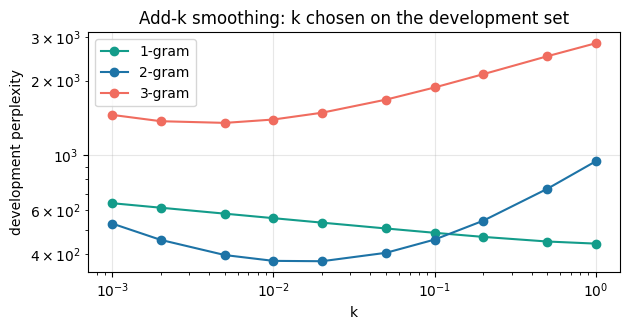

best k for the bigram model: 0.02


In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6.4, 3.4))
for n, color in zip((1, 2, 3), ("#139C8A", "#1D73A6", "#F06C5F")):
    plt.plot(KS, dev_ppl[n], marker="o", color=color, label=f"{n}-gram")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("k"); plt.ylabel("development perplexity")
plt.title("Add-k smoothing: k chosen on the development set")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

best_k = KS[min(range(len(KS)), key=lambda i: dev_ppl[2][i])]
print("best k for the bigram model:", best_k)

With k = 1 the bigram model is *worse* than the unigram model: add-one moves too much probability mass to the millions of unseen bigrams, as the adjusted counts of the lecture showed. A small k works much better. The trigram model, whose counts are far sparser, stays worse than the bigram model for every k: add-k is not a good way to smooth a language model (section 3.6.2).

## 4. Interpolation

Mix the trigram, bigram and unigram estimates with weights that sum to 1 (Eq. 3.29). The trigram and bigram terms are maximum likelihood estimates; the unigram term is add-one smoothed, so that a word never seen in training still gets some probability. The weights are chosen on the development set: first with a simple grid search, then with the EM algorithm mentioned in the book (Jelinek and Mercer 1980).

In [9]:
def p_ml(n, context, word):
    c = models[n].get(context)
    return c[word] / totals[n][context] if c and word in c else 0.0

def components(context, word):
    """unigram (add-one), bigram (MLE) and trigram (MLE) estimates of P(word | context)"""
    return (p_addk(1, (), word, 1), p_ml(2, context[-1:], word), p_ml(3, context[-2:], word))

def interpolated(lambdas):
    return lambda ctx, w: sum(l * p for l, p in zip(lambdas, components(ctx, w)))

grid = [(a / 10, b / 10, round(1 - a / 10 - b / 10, 1)) for a in range(1, 11) for b in range(0, 11 - a)]
scores = [(evaluate(interpolated(l), dev_sents, 3)[1], l) for l in grid]
best_ppl, best_l = min(scores)
print(f"{len(grid)} weight vectors tried; best (unigram, bigram, trigram) = {best_l}, development perplexity {best_ppl:.1f}")

55 weight vectors tried; best (unigram, bigram, trigram) = (0.5, 0.4, 0.1), development perplexity 214.6


EM for the interpolation weights: for every token of the development set, compute how much each of the three estimates contributes to the mixture (its share of the interpolated probability), then set each weight to the average share, and repeat. Each iteration can only increase the probability of the development set.

In [10]:
dev_tokens = [(tuple(t[i - 2:i]), t[i]) for t in sentences_to_tokens(dev_sents, 3) for i in range(2, len(t))]
comps = [components(ctx, w) for ctx, w in dev_tokens]
lambdas = [1 / 3, 1 / 3, 1 / 3]
for it in range(1, 21):
    shares = [0.0, 0.0, 0.0]
    for ps in comps:
        z = sum(l * p for l, p in zip(lambdas, ps))
        for j in range(3):
            shares[j] += lambdas[j] * ps[j] / z
    lambdas = [s / len(comps) for s in shares]
    if it in (1, 2, 3, 5, 10, 20):
        H = -sum(math.log2(sum(l * p for l, p in zip(lambdas, ps))) for ps in comps) / len(comps)
        print(f"iteration {it:2d}: lambdas = {[round(l, 3) for l in lambdas]}, development perplexity {2 ** H:.1f}")

iteration  1: lambdas = [0.491, 0.356, 0.153], development perplexity 217.9
iteration  2: lambdas = [0.516, 0.378, 0.106], development perplexity 214.9
iteration  3: lambdas = [0.519, 0.396, 0.085], development perplexity 214.1
iteration  5: lambdas = [0.517, 0.415, 0.068], development perplexity 213.6
iteration 10: lambdas = [0.515, 0.427, 0.057], development perplexity 213.5
iteration 20: lambdas = [0.515, 0.429, 0.056], development perplexity 213.5


Only now, with k and the weights fixed, we evaluate once on the test set. The same numbers are cross-entropies in bits per token and perplexities: 2 to the first gives the second.

In [11]:
for name, p, n in [("unigram, add-one", lambda c, w: p_addk(1, c, w, 1), 1),
                   (f"bigram, add-k (k = {best_k})", lambda c, w: p_addk(2, c, w, best_k), 2),
                   ("trigram interpolated, EM weights", interpolated(lambdas), 3)]:
    H, pp = evaluate(p, test_sents, n)
    print(f"{name:34s} cross-entropy {H:5.2f} bits per token   perplexity {pp:6.1f}   (2^{H:.2f} = {2 ** H:.1f})")

unigram, add-one                   cross-entropy  9.01 bits per token   perplexity  515.2   (2^9.01 = 515.2)
bigram, add-k (k = 0.02)           cross-entropy  8.93 bits per token   perplexity  486.5   (2^8.93 = 486.5)
trigram interpolated, EM weights   cross-entropy  8.15 bits per token   perplexity  284.9   (2^8.15 = 284.9)


## 5. Stupid backoff

Stupid backoff (Eq. 3.31) uses the relative frequency of the longest n-gram that has been seen, and otherwise backs off to a shorter one with a fixed weight λ = 0.4, down to the unigram count(w) / N. The scores are not probabilities: summed over the vocabulary they usually exceed 1. First the example of the lecture on the *I am Sam* corpus, then a few contexts of the docstring corpus.

In [12]:
def stupid_backoff(counts_by_n, N_tokens, context, word, lam=0.4):
    """S(word | context) with backoff weight lam; counts_by_n[n] are the n-gram counts, the context has n-1 words."""
    n = len(context) + 1
    if n == 1:
        return counts_by_n[1][()][word] / N_tokens
    c = counts_by_n[n].get(tuple(context))
    if c and c[word] > 0:
        return c[word] / sum(c.values())
    return lam * stupid_backoff(counts_by_n, N_tokens, context[1:], word, lam)

sam_counts = {1: uni, 2: bi, 3: tri}
for w in ("am", "do", "Sam"):
    print(f"S({w} | Sam I) = {stupid_backoff(sam_counts, N, ('Sam', 'I'), w):.3f}")
print("sum over the 11 next tokens:", round(sum(stupid_backoff(sam_counts, N, ("Sam", "I"), w) for w in VOCAB), 3))
print()
N_train = sum(models[1][()].values())
for ctx in [("of", "the"), ("return", "the"), ("if", "the")]:
    total = sum(stupid_backoff(models, N_train, ctx, w) for w in vocab)
    print(f"context {' '.join(ctx):10s}: scores sum to {total:.3f}")

S(am | Sam I) = 1.000
S(do | Sam I) = 0.133
S(Sam | Sam I) = 0.019
sum over the 11 next tokens: 1.265

context of the    : scores sum to 1.343
context return the: scores sum to 1.427
context if the    : scores sum to 1.398


## 6. Entropy and codes

The entropy H(X) = -Σ p(x) log<sub>2</sub> p(x) (Eq. 3.32) is a lower bound on the average number of bits needed to encode the outcome. The horse race of the lecture, and the examples of exercise 10 of the exercise sheet:

In [13]:
def entropy(probs):
    return -sum(p * math.log2(p) for p in probs if p > 0)

def average_length(probs, code):
    return sum(p * len(c) for p, c in zip(probs, code))

horses = [1/2, 1/4, 1/8, 1/16, 1/64, 1/64, 1/64, 1/64]
print("horse race:", entropy(horses), "bits; code 0, 10, 110, ...:", average_length(horses, ["0", "10", "110", "1110", "111100", "111101", "111110", "111111"]), "bits")
print("eight equally likely horses:", entropy([1/8] * 8), "bits")
print("four horses 1/2, 1/4, 1/8, 1/8:", entropy([1/2, 1/4, 1/8, 1/8]), "bits; code 0, 10, 110, 111:", average_length([1/2, 1/4, 1/8, 1/8], ["0", "10", "110", "111"]))
print(f"a fair die: {entropy([1/6] * 6):.3f} bits; code 00, 01, 100, 101, 110, 111: {average_length([1/6] * 6, ['00', '01', '100', '101', '110', '111']):.3f} bits")

horse race: 2.0 bits; code 0, 10, 110, ...: 2.0 bits
eight equally likely horses: 3.0 bits
four horses 1/2, 1/4, 1/8, 1/8: 1.75 bits; code 0, 10, 110, 111: 1.75
a fair die: 2.585 bits; code 00, 01, 100, 101, 110, 111: 2.667 bits


## 7. Cross-entropy and perplexity

The cross-entropy of a model m on data from a distribution p is an upper bound on the entropy of p (Eq. 3.41). For colors drawn independently from p, the per-token cross-entropy is -Σ p(x) log<sub>2</sub> m(x) (exercise 11 of the exercise sheet):

In [14]:
def cross_entropy(p, m):
    return -sum(px * math.log2(m[x]) for x, px in p.items())

p = {"red": 0.5, "blue": 0.25, "green": 0.25}
A = {"red": 1/3, "blue": 1/3, "green": 1/3}
B = {"red": 0.8, "blue": 0.1, "green": 0.1}
print(f"H(p) = {entropy(p.values()):.3f} bits")
for name, m in [("p itself", p), ("model A", A), ("model B", B)]:
    H = cross_entropy(p, m)
    print(f"H(p, {name:8s}) = {H:.3f} bits   perplexity {2 ** H:.2f}")

H(p) = 1.500 bits
H(p, p itself) = 1.500 bits   perplexity 2.83
H(p, model A ) = 1.585 bits   perplexity 3.00
H(p, model B ) = 1.822 bits   perplexity 3.54


The Shannon-McMillan-Breiman theorem (Eq. 3.38 and 3.40) says that for a stationary and ergodic process we can estimate these quantities from a single long sequence: -1/n log<sub>2</sub> of its probability. A small Markov chain over the three colors is such a process. We compute its true entropy rate, sample longer and longer sequences from it, and measure the average negative log probability under the chain itself and under two simpler models: the uniform model, and a unigram model with the long-run frequencies of the colors. The estimates converge, and the two simpler models stay above the entropy rate.

In [15]:
COLORS = ["red", "blue", "green"]
T = {"red":   {"red": 0.8, "blue": 0.1, "green": 0.1},     # P(next color | current color)
     "blue":  {"red": 0.3, "blue": 0.4, "green": 0.3},
     "green": {"red": 0.5, "blue": 0.25, "green": 0.25}}

pi = {c: 1 / 3 for c in COLORS}                  # stationary distribution, by power iteration
for _ in range(200):
    pi = {c: sum(pi[a] * T[a][c] for a in COLORS) for c in COLORS}
rate = sum(pi[a] * entropy(T[a].values()) for a in COLORS)
print("stationary distribution:", {c: round(v, 3) for c, v in pi.items()})
print(f"entropy rate of the chain: {rate:.4f} bits per color; entropy of the stationary unigram: {entropy(pi.values()):.4f}")

rng = random.Random(2026)
seq = [rng.choices(COLORS, weights=[pi[c] for c in COLORS])[0]]
while len(seq) < 100000:
    seq.append(rng.choices(COLORS, weights=[T[seq[-1]][c] for c in COLORS])[0])

lengths = [10, 30, 100, 300, 1000, 3000, 10000, 30000, 100000]
def per_token(logp_fn):
    out, s = [], 0.0
    for i, x in enumerate(seq):
        s += logp_fn(i, x)
        if i + 1 in lengths:
            out.append(-s / (i + 1))
    return out
est_chain = per_token(lambda i, x: math.log2(pi[x] if i == 0 else T[seq[i - 1]][x]))
est_uniform = per_token(lambda i, x: math.log2(1 / 3))
est_unigram = per_token(lambda i, x: math.log2(pi[x]))
for n, a, b, c in zip(lengths, est_chain, est_unigram, est_uniform):
    print(f"n = {n:6d}   chain {a:.4f}   unigram {b:.4f}   uniform {c:.4f}")

stationary distribution: {'red': 0.664, 'blue': 0.177, 'green': 0.159}
entropy rate of the chain: 1.1289 bits per color; entropy of the stationary unigram: 1.2568


n =     10   chain 0.7904   unigram 0.7820   uniform 1.5850
n =     30   chain 1.1659   unigram 1.3159   uniform 1.5850
n =    100   chain 1.1329   unigram 1.3418   uniform 1.5850
n =    300   chain 1.0858   unigram 1.2406   uniform 1.5850
n =   1000   chain 1.0679   unigram 1.2354   uniform 1.5850
n =   3000   chain 1.0852   unigram 1.2233   uniform 1.5850
n =  10000   chain 1.1002   unigram 1.2322   uniform 1.5850
n =  30000   chain 1.1136   unigram 1.2416   uniform 1.5850
n = 100000   chain 1.1225   unigram 1.2529   uniform 1.5850


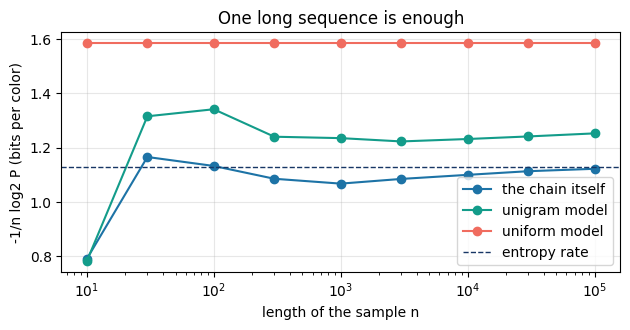

In [16]:
plt.figure(figsize=(6.4, 3.4))
plt.plot(lengths, est_chain, marker="o", color="#1D73A6", label="the chain itself")
plt.plot(lengths, est_unigram, marker="o", color="#139C8A", label="unigram model")
plt.plot(lengths, est_uniform, marker="o", color="#F06C5F", label="uniform model")
plt.axhline(rate, color="#173665", linestyle="--", linewidth=1, label="entropy rate")
plt.xscale("log"); plt.xlabel("length of the sample n"); plt.ylabel("-1/n log2 P (bits per color)")
plt.title("One long sequence is enough")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

The estimate under the chain itself converges to the entropy rate; the unigram and the uniform models converge to higher values, their cross-entropies. Their perplexities, 2 to these values, are the perplexities each model would have on a long test set from the chain.

## 8. What to do next

- The exercise sheet of this lecture: exercises 2, 3, 6, 7 and 8 can be checked with `mle`, `addk` and `sentence_prob` on the corpora of section 1 (for exercises 3 and 7 use the modified corpus, and follow the book in counting `<s>` like any other token); exercise 9 with `stupid_backoff`; exercises 10 and 11 with `entropy` and `cross_entropy`.
- Change the development and test modules, or the list of modules, and see how the best k and the best weights change.
- Replace the add-one unigram of section 4 with an add-k unigram, or add a 4-gram term to the interpolation, and compare the perplexities on the development set.
- Textbook exercise 3.11 asks for a program that computes the perplexity of a test set: `evaluate` is one, for any estimator.